# Import library

In [129]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Read dataset

In [130]:
data = pd.read_csv('Credit Card Customer Data.csv')

In [131]:
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


# Data preparation

In [133]:
# Drop kolom yang tidak di perlukan
X = data.drop(['Sl_No', 'Customer Key'], axis=1)

In [134]:
print(X)

     Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
0              100000                   2                  1   
1               50000                   3                  0   
2               50000                   7                  1   
3               30000                   5                  1   
4              100000                   6                  0   
..                ...                 ...                ...   
655             99000                  10                  1   
656             84000                  10                  1   
657            145000                   8                  1   
658            172000                  10                  1   
659            167000                   9                  0   

     Total_visits_online  Total_calls_made  
0                      1                 0  
1                     10                 9  
2                      3                 4  
3                      1                 4  
4     

# Data Cleaning

In [135]:
# Cek missing value
X.isnull().sum()

Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [136]:
# Cek data duplikat
X.duplicated().sum()

11

In [137]:
# Hapus data duplikat
X.drop_duplicates(inplace=True)

In [138]:
# Mengecek kembali data duplikat
X.duplicated().sum()

0

In [139]:
# Cek jumlah baris 
print("Jumlah baris sebelum:", len(data))
print("Jumlah baris setelah hapus duplikat:", len(X))

Jumlah baris sebelum: 660
Jumlah baris setelah hapus duplikat: 649


In [140]:
# Fitur-fitur yang dipertimbangkan untuk penanganan outlier
list_numerik_features = ['Avg_Credit_Limit','Total_Credit_Cards','Total_visits_bank','Total_visits_online','Total_calls_made']

In [141]:
# Menjumlahkan yang terindikasi outliers
Q1 = X[list_numerik_features].quantile(0.25)
Q3 = X[list_numerik_features].quantile(0.75)
IQR = Q3 - Q1
outliers_count_specified = ((X[list_numerik_features] < (Q1 - 1.5 * IQR)) | (X[list_numerik_features] > (Q3 + 1.5 * IQR))).sum()
outliers_count_specified

Avg_Credit_Limit       38
Total_Credit_Cards      0
Total_visits_bank       0
Total_visits_online    37
Total_calls_made        0
dtype: int64

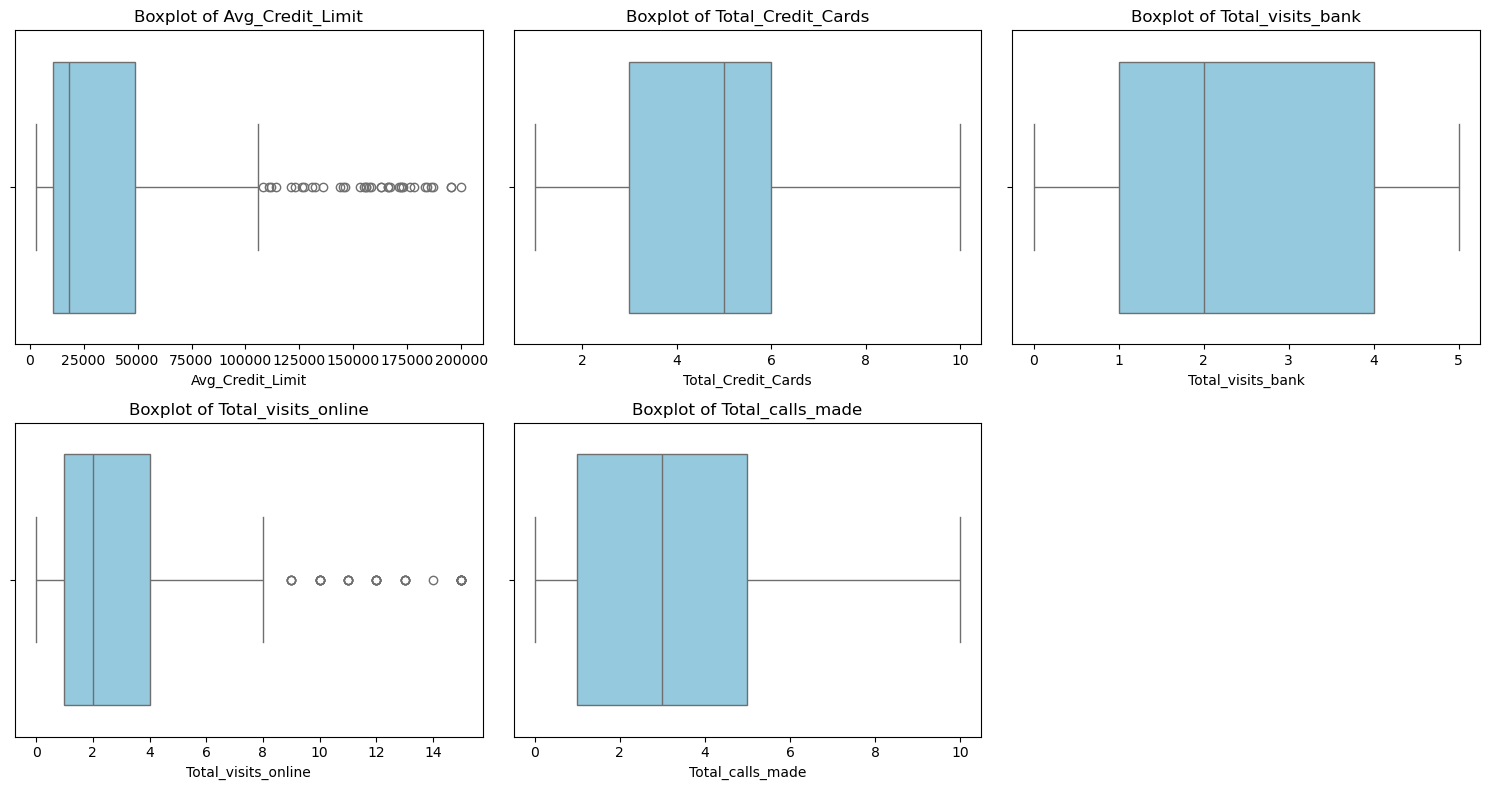

In [142]:
# membuat boxplot untuk fitur yang terindikasi outlier
plt.figure(figsize=(15, 8))
for i, feature in enumerate(list_numerik_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=X[feature], color='skyblue')
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

In [143]:
# Handling outlier
def handling_outliers_iqr(X, column):
  Q1 = X[column].quantile(0.25)
  Q3 = X[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  X[column] = np.where(X[column] < lower_bound, lower_bound, X[column])
  X[column] = np.where(X[column] > upper_bound, upper_bound, X[column])

columns_with_outliers = ['Avg_Credit_Limit','Total_Credit_Cards','Total_visits_bank','Total_visits_online','Total_calls_made']
for column in columns_with_outliers:
  handling_outliers_iqr(X, column)

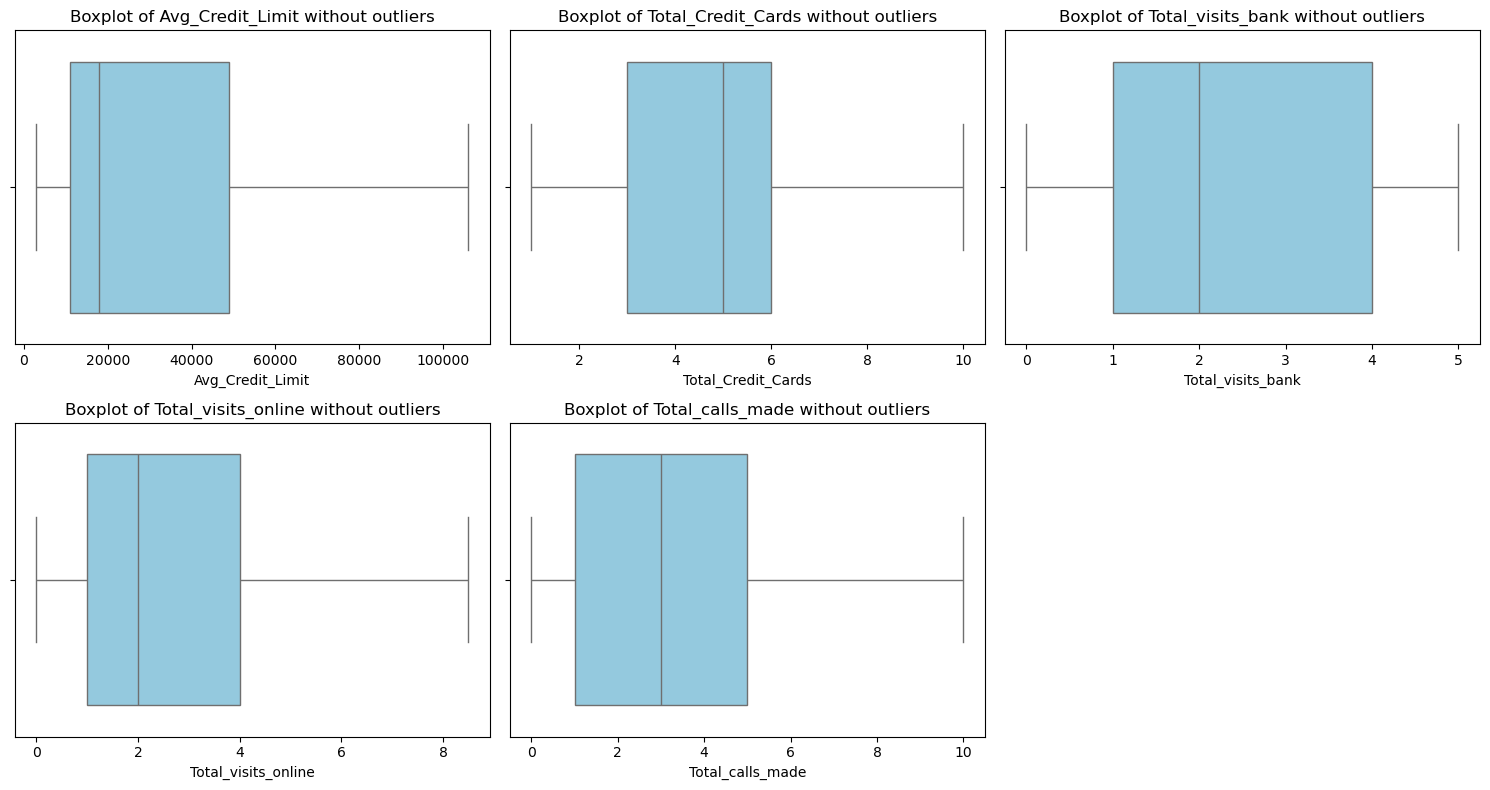

In [144]:
# membuat boxplot setelah penanganan outlier
plt.figure(figsize=(15, 8))
for i, feature in enumerate(columns_with_outliers):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=X[feature], color='skyblue')
    plt.title(f'Boxplot of {feature} without outliers')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

# Preprocessing

In [145]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [146]:
X_scaled

array([[ 2.36693579, -1.24708705, -0.86060646, -0.62324389, -1.24844298],
       [ 0.62701493, -0.78670054, -1.47640975,  2.68678297,  1.88123746],
       [ 0.62701493,  1.05484553, -0.86060646,  0.25942994,  0.14252611],
       ...,
       [ 2.57572629,  1.51523205, -0.86060646,  2.68678297, -0.9007007 ],
       [ 2.57572629,  2.43600508, -0.86060646,  2.68678297, -1.24844298],
       [ 2.57572629,  1.97561857, -1.47640975,  2.68678297, -0.55295843]])

# Data Visualization

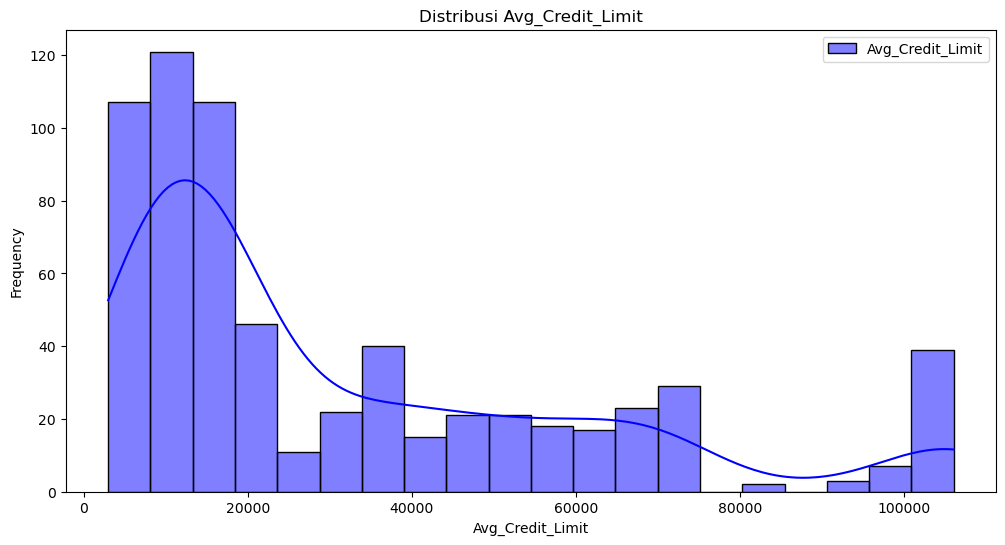

In [147]:
# Histogram untuk distribusi data
plt.figure(figsize=(12, 6))
sns.histplot(X['Avg_Credit_Limit'], kde=True, color='blue', label='Avg_Credit_Limit', bins=20)
plt.title('Distribusi Avg_Credit_Limit')
plt.xlabel('Avg_Credit_Limit')
plt.ylabel('Frequency')
plt.legend()
plt.show()

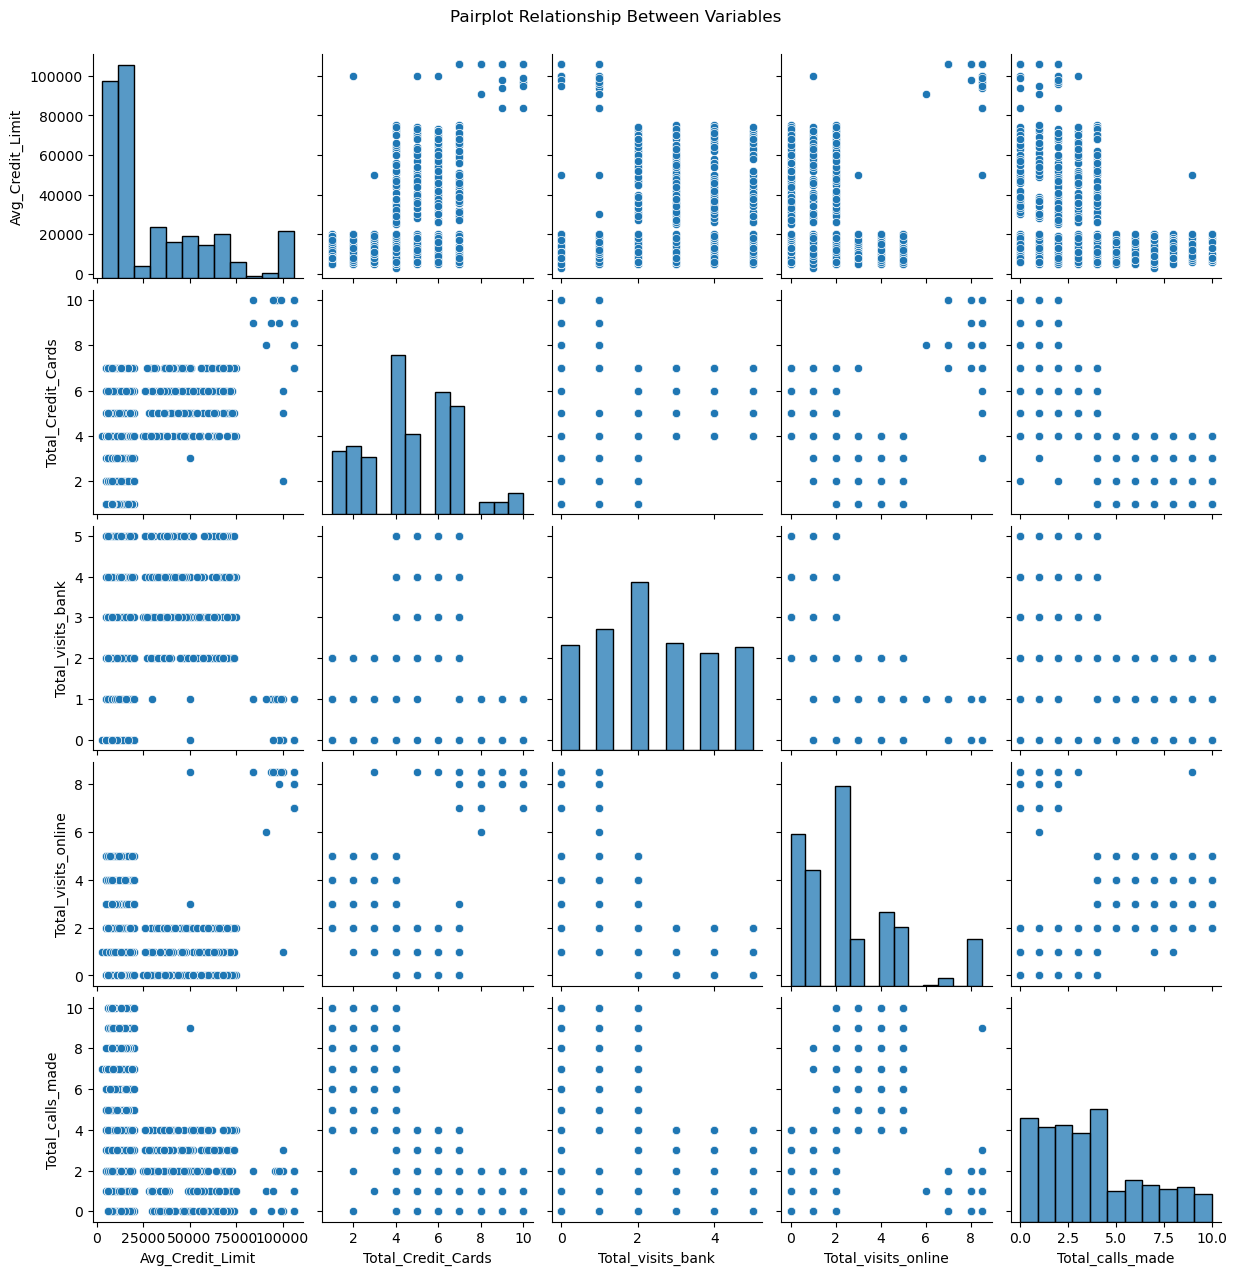

In [148]:
# Visualisasi Pairplot untuk melihat hubungan antar kolom numerik
sns.pairplot(X[['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']])
plt.suptitle('Pairplot Relationship Between Variables', y=1.02)
plt.show()


<Axes: >

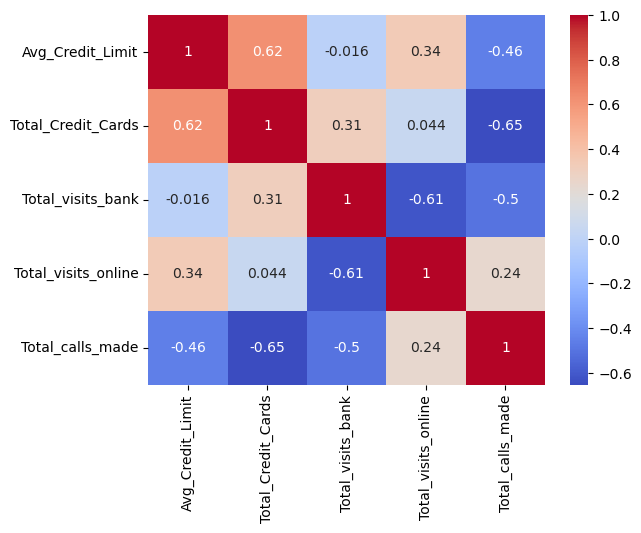

In [149]:
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')

# Elbow method

Text(5, 1297.6077964004448, 'Possible elbow point')

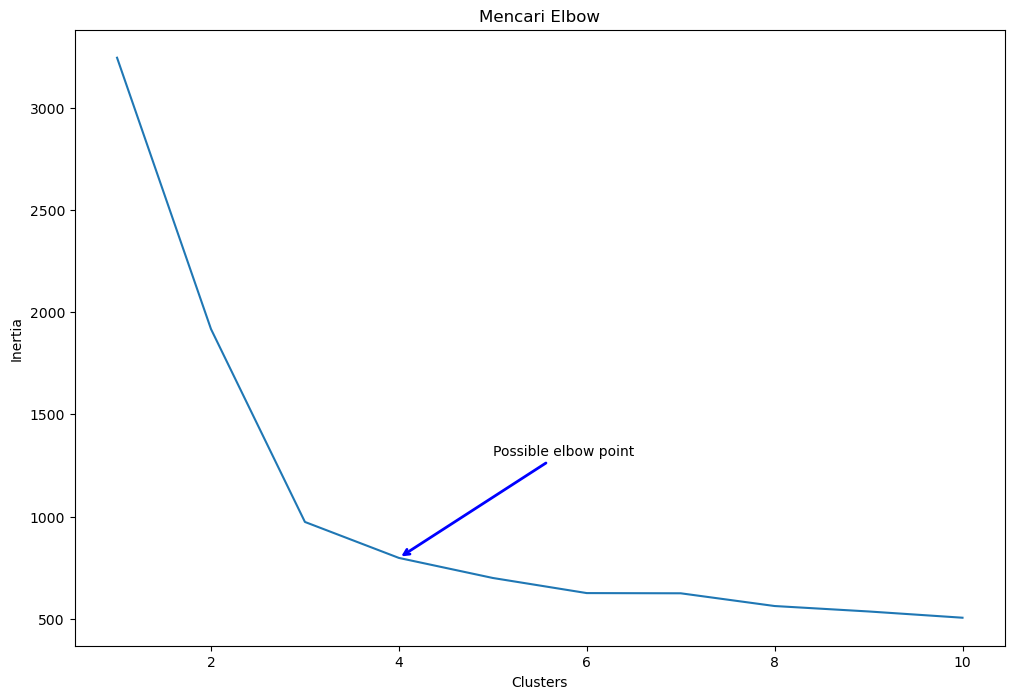

In [150]:
# Elbow Method Plot
clusters = []
for i in range(1, 11):
    km = KMeans(n_clusters=i).fit(X_scaled)
    clusters.append(km.inertia_)

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=list(range(1, 11)), y=clusters, ax=ax)
ax.set_title('Mencari Elbow')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')

elbow_x = 4
elbow_y = clusters[elbow_x - 1]

ax.annotate('Possible elbow point',
            xy=(elbow_x, elbow_y),
            xytext=(elbow_x + 1, elbow_y + 500),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2))


# Clustering

In [151]:
n_clust = 4
kmean = KMeans(n_clusters=n_clust, random_state=42).fit(X_scaled)
X['Labels'] = kmean.labels_

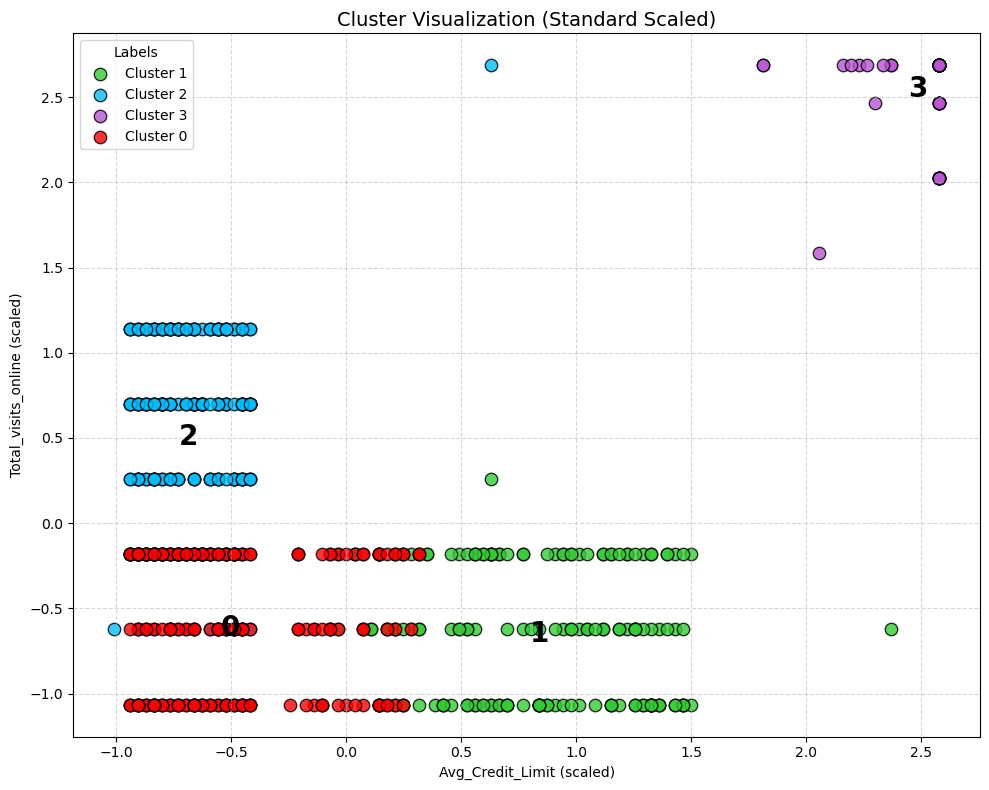

In [152]:
# Warna per cluster
colors = ['red', 'limegreen', 'deepskyblue', 'mediumorchid']

plt.figure(figsize=(10, 8))

# Ambil data scaled sebagai NumPy array
x_scaled = X_scaled[:, X.columns.get_loc('Avg_Credit_Limit')]
y_scaled = X_scaled[:, X.columns.get_loc('Total_visits_online')]

# Plot masing-masing cluster
for label in X['Labels'].unique():
    mask = X['Labels'] == label
    plt.scatter(
        x_scaled[mask],
        y_scaled[mask],
        c=colors[label],
        label=f'Cluster {label}',
        s=80,
        edgecolors='black',
        alpha=0.8
    )

# Tambahkan label besar di tengah cluster
for label in X['Labels'].unique():
    mask = X['Labels'] == label
    x_mean = x_scaled[mask].mean()
    y_mean = y_scaled[mask].mean()
    plt.annotate(
        str(label),
        (x_mean, y_mean),
        ha='center',
        va='center',
        fontsize=20,
        weight='bold',
        color='black'
    )

# Label dan layout
plt.title('Cluster Visualization (Standard Scaled)', fontsize=14)
plt.xlabel('Avg_Credit_Limit (scaled)')
plt.ylabel('Total_visits_online (scaled)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Labels')
plt.tight_layout()
plt.show()

In [153]:
print(X)

     Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
0            100000.0                 2.0                1.0   
1             50000.0                 3.0                0.0   
2             50000.0                 7.0                1.0   
3             30000.0                 5.0                1.0   
4            100000.0                 6.0                0.0   
..                ...                 ...                ...   
655           99000.0                10.0                1.0   
656           84000.0                10.0                1.0   
657          106000.0                 8.0                1.0   
658          106000.0                10.0                1.0   
659          106000.0                 9.0                0.0   

     Total_visits_online  Total_calls_made  Labels  
0                    1.0               0.0       1  
1                    8.5               9.0       2  
2                    3.0               4.0       1  
3                  

In [154]:
X.to_excel("output_cluster.xlsx")